<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 171.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 180.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 136.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 143.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


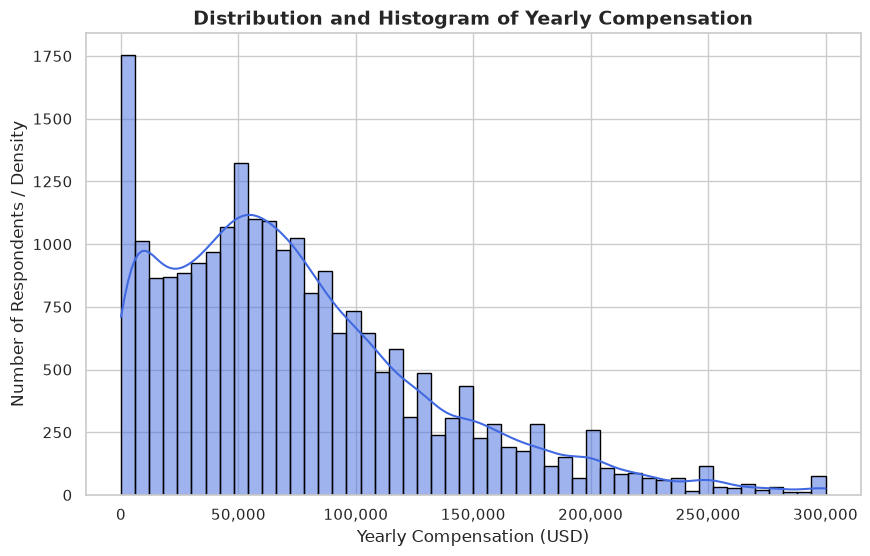

In [3]:
# 1. Filter out extreme outliers to make the plot readable (optional but highly recommended)
# This filters for compensation less than $300,000. Adjust as needed.
filtered_comp = df[df['ConvertedCompYearly'] <= 300000]['ConvertedCompYearly']

# 2. Set the plot style and size
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Plot the Histogram and Distribution (KDE) Curve together
sns.histplot(filtered_comp, kde=True, bins=50, color='royalblue', edgecolor='black')

# 4. Add labels and a title
plt.title('Distribution and Histogram of Yearly Compensation', fontsize=14, fontweight='bold')
plt.xlabel('Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Number of Respondents / Density', fontsize=12)

# 5. Format X-axis with thousands separators for better readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 6. Display the plot
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [5]:
# Filter the DataFrame for full-time employed respondents and calculate the median compensation
df[df['Employment'] == 'Employed full-time']['ConvertedCompYearly'].median()

nan

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



/tmp/ipykernel_301/368383536.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(

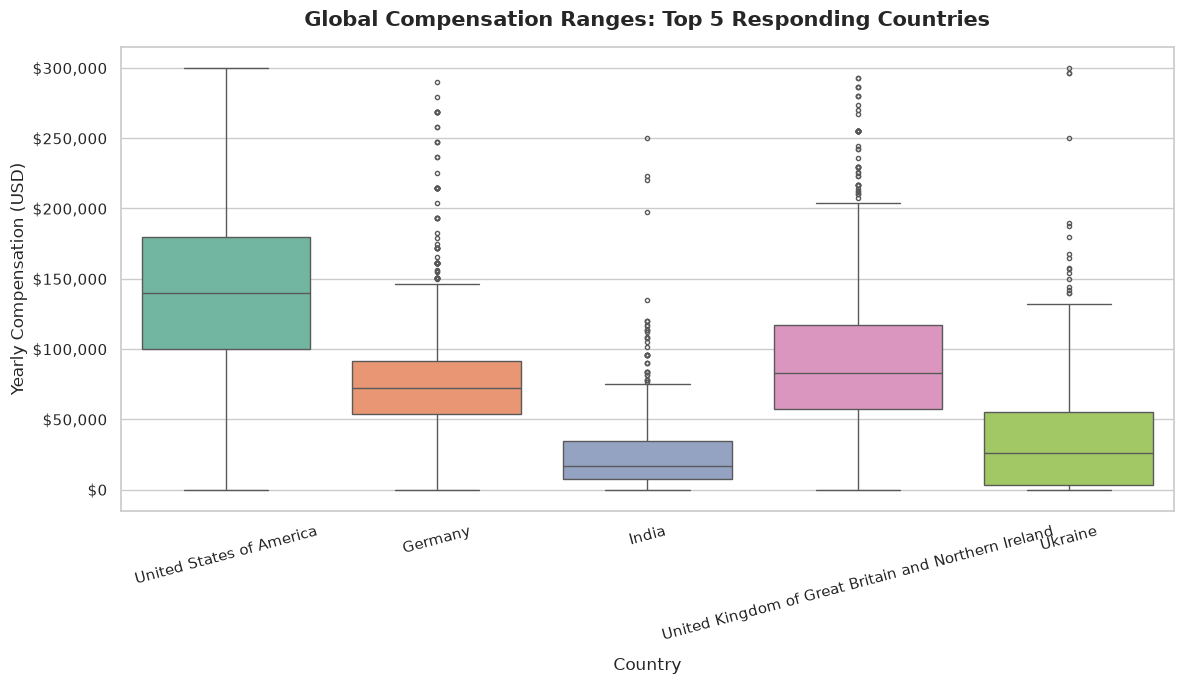

In [6]:
# 1. Identify the top 5 countries with the most survey respondents
top_countries = df['Country'].value_counts().nlargest(5).index

# 2. Filter the main DataFrame to include only these top countries
df_filtered = df[df['Country'].isin(top_countries)]

# 3. Clean the target column by dropping null values and removing extreme outliers
# Filtering compensation up to $300,000 ensures the boxes and whiskers are clear.
df_filtered = df_filtered[df_filtered['ConvertedCompYearly'] <= 300000].dropna(subset=['ConvertedCompYearly'])

# 4. Set the chart theme and dimensions
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 5. Generate the Box Plot
# Ordering by the top_countries index guarantees consistent sorting from left to right.
sns.boxplot(
    data=df_filtered, 
    x='Country', 
    y='ConvertedCompYearly', 
    order=top_countries,
    palette='Set2',
    fliersize=3  # Controls the size of the outlier dots
)

# 6. Customize the visuals and formatting
plt.title('Global Compensation Ranges: Top 5 Responding Countries', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=12, labelpad=10)
plt.ylabel('Yearly Compensation (USD)', fontsize=12)
plt.xticks(rotation=15) # Slightly tilt labels to prevent overlap

# Format the Y-axis numbers with thousands commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

# 7. Render the plot
plt.tight_layout()
plt.show()


<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [7]:
# 1. Calculate the 1st (25th) and 3rd (75th) quartiles
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# 2. Compute the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the original DataFrame to create a new, refined DataFrame
df_refined = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

# 5. Print a quick summary of the transformation
print(f"Original dataset rows: {df.shape[0]}")
print(f"Refined dataset rows (outliers removed): {df_refined.shape[0]}")
print(f"Lower Bound: ${lower_bound:,.2f} | Upper Bound: ${upper_bound:,.2f}")


Original dataset rows: 65437
Refined dataset rows (outliers removed): 22457
Lower Bound: $-80,177.25 | Upper Bound: $220,860.75

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


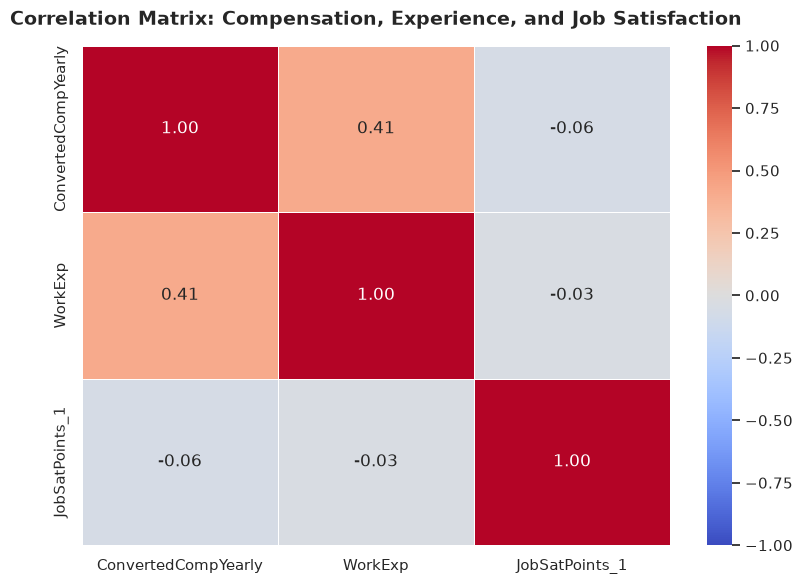

In [8]:
## 1. Select the relevant columns from your refined DataFrame
columns_to_correlate = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
correlation_matrix = df_refined[columns_to_correlate].corr(numeric_only=True)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(8, 6))

# 3. Create the Seaborn Heatmap
# 'annot=True' prints the exact correlation numbers inside the blocks.
# 'cmap' sets the color scheme (coolwarm transitions visually from blue to red).
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)

# 4. Add formatting and title
plt.title('Correlation Matrix: Compensation, Experience, and Job Satisfaction', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# 5. Display the plot
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


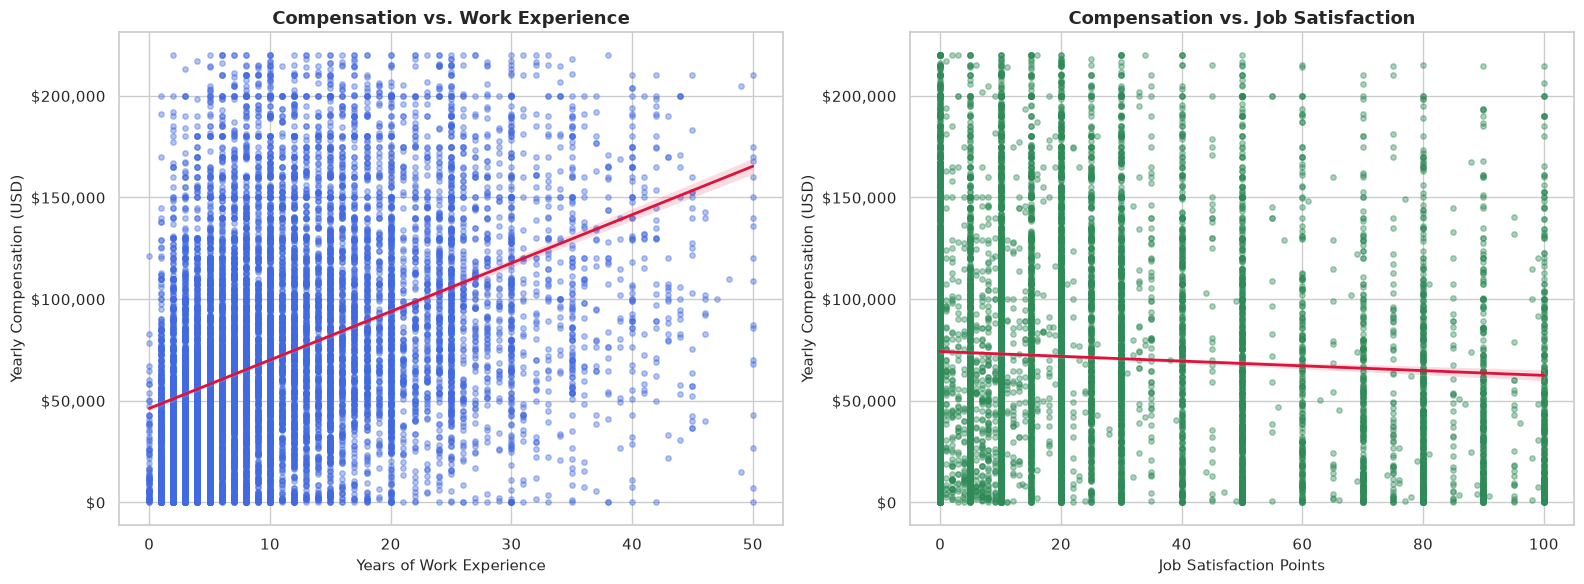

In [9]:
# Set the theme and create a two-panel side-by-side plot layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Compensation vs. Work Experience ---
sns.regplot(
    data=df_refined, 
    x='WorkExp', 
    y='ConvertedCompYearly', 
    ax=axes[0],
    scatter_kws={'alpha':0.4, 'color':'royalblue', 's':15}, # Make points slightly translucent to handle overlap
    line_kws={'color':'crimson', 'linewidth':2}             # Red trend line
)
axes[0].set_title('Compensation vs. Work Experience', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Years of Work Experience', fontsize=11)
axes[0].set_ylabel('Yearly Compensation (USD)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

# --- Plot 2: Compensation vs. Job Satisfaction ---
sns.regplot(
    data=df_refined, 
    x='JobSatPoints_1', 
    y='ConvertedCompYearly', 
    ax=axes[1],
    scatter_kws={'alpha':0.4, 'color':'seagreen', 's':15}, 
    line_kws={'color':'crimson', 'linewidth':2}
)
axes[1].set_title('Compensation vs. Job Satisfaction', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Job Satisfaction Points', fontsize=11)
axes[1].set_ylabel('Yearly Compensation (USD)', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

# Final layout adjustment and render
plt.tight_layout()
plt.show()


<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
